# Netflix Top-10 engagement momentum — a quantitative teardown 🔬
### engagement-momentum signal · predictive regression · OLS vs Newey-West · label-shuffle placebo · seed-robust null · horizon-overlap artifact · costs & borrow · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Alt-data_edge%3F: Mirage](https://img.shields.io/badge/Alt--data_edge%3F-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether streaming-engagement momentum predicts NFLX / XLY forward returns, and dissect why the one 'significant' result is an **overlapping-window false positive**.

> ⚠️ **Not investment advice.** There is **no real tape** for this study (no free point-in-time Netflix Top-10 hours feed), so it is **synthetic-only** and capped at `WEAK`/`NONE`. Numbers are the null synthetic world (seed 551, world fp `a31af2c4d9d7`, as-of 2026-06-30). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from netflix_top10 import data, strategy as st

SEED = 551

# There is NO real tape for this study (no free point-in-time Top-10 hours feed).
REAL = data.fetch_series(fetch=False)
HAVE_REAL = not REAL.empty
print("real streaming-engagement tape present:", HAVE_REAL, "(synthetic-only by design)")

# The offline core: the NULL synthetic world (beta=0) is the honest headline.
WEEKLY, TRUTH = data.synthetic_series(beta=0.0, seed=SEED)
print(f"synthetic NULL world: {len(WEEKLY)} weekly rows, fp {data.fingerprint(WEEKLY)}")


real streaming-engagement tape present: False (synthetic-only by design)
synthetic NULL world: 197 weekly rows, fp a31af2c4d9d7


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | No real tape (synthetic-only ⇒ not `REAL`). Null world: NFLX slope **-0.0106**, naive OLS *t* **-2.03** but overlap-robust NW *t* **-1.48**; 20-seed mean NW *t* **+0.11**, **0/20** clear \|*t*\| ≥ 2. |
| **Tradability** | `MIRAGE` | Timing long/flat **-3.6%/yr** gross (**-4.4%** net) vs buy-and-hold **+21.8%/yr**; long/short **-25.7%/yr**. |
| **Alt-data edge?** | `MIRAGE` | XLY spillover flat (*t* -0.47); the 'edge' is a single-seed overlap artifact, and real reports lag & are widely covered (priced in). |

> 💡 In plain words: the engine works (the synthetic control proves it), but there is no data to test on and the honest, overlap-corrected, seed-averaged link is a flat zero.

## 1 · The claim, steelmanned

Let $m_t$ be standardised engagement momentum at week $t$ and $r_{t\to t+h}$ the forward $h$-week return.

- **H₁ (predictive).** In $r_{t\to t+h} = \alpha + \beta\, m_t + \varepsilon$, $\beta > 0$ at a robust *t* ≥ 2 for NFLX.
- **H₂ (spillover).** The same $\beta > 0$ for XLY (consumer discretionary).
- **H₃ (robustness).** The sign/size of $\beta$ is stable across forward horizons and RNG seeds — *not* an overlapping-window artifact.
- **H₄ (net).** A timing rule on $m_t$ beats buy-and-hold after costs and borrow.

We find **H₁ not supported** (naive *t* is an overlap false positive; NW *t* below the bar and seed-averaged ≈ 0), **H₂ rejected** (flat), **H₃ rejected** (the naive *t* grows with horizon purely from overlap), and **H₄ rejected** (timing loses to buy-and-hold).

## 2 · So what? — what rides on each answer

Two structural reasons this is hard: (a) **no data** — the public Top-10 hours series is short (2021+), methodology-revised, and not a free machine-readable point-in-time feed, so a synthetic-only study cannot earn `REAL`; and (b) **overlap** — weekly signals against multi-week forward returns share most of their observations, so a naive OLS *t* massively overstates significance. The Newey-West correction and seed-averaging exist precisely to un-fool that. Same alt-data family as [257 AAII](../../257-aaii-sentiment/) / [335 Buzz](../../335-buzz-sentiment-etf/).

## 3 · How we'd know — the protocol

- **Signal.** $m_t = z(\text{engagement}_t - \overline{\text{engagement}}_{t-8:t})$ — standardised gap of the index above its trailing 8-week mean (formed from data ≤ $t$).
- **Regression.** OLS of $r_{t\to t+4}$ on $m_t$; report the slope, the **naive OLS *t***, and the **Newey-West (overlap-robust) *t***.
- **Placebo.** Shuffle $m_t$ against the forward returns (2000 perms); tail probability of \|slope\|.
- **Robustness.** Sweep forward horizons {2,4,8,13} weeks and RNG seeds.
- **Frictions.** Long/flat and long/short timing, 5 bps/side one-way costs, 100 bps/yr borrow on the short leg.
- **Positive control.** Plant $\beta > 0$ and average the NW *t* over 25 seeds (house rule) — vs the null.

Timing: $m_t$ uses data ≤ $t$ (no look-ahead); the position is entered at week $t$'s close and held over the forward window — one documented execution lag.

## 4 · The teardown

### 4a · The predictive regression — H₁ (and the OLS-vs-Newey-West gap)

The headline test, with *both* standard errors so you can see the overlap inflation.

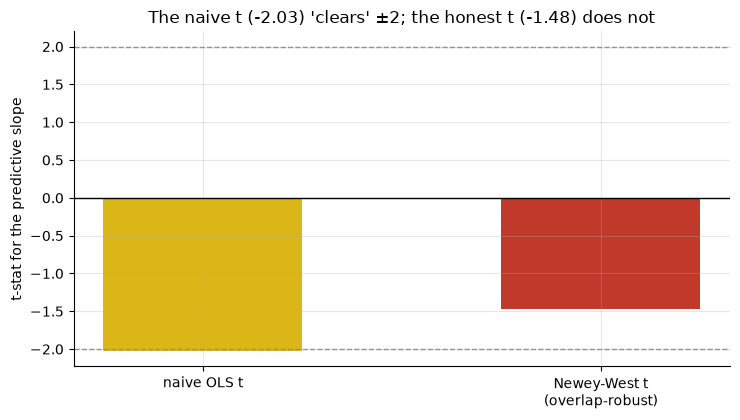

slope -0.0106 | naive OLS t -2.03 | NW t -1.48 | corr -0.14 | placebo p 0.046


In [2]:
reg = st.predictive_regression(WEEKLY, 'nflx_fwd')
p = st.placebo_pvalue(WEEKLY, 'nflx_fwd', n_perm=2000, seed=SEED)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['naive OLS t','Newey-West t\n(overlap-robust)'], [reg['slope_t'], reg['t_nw']],
       color=[AMBER, RED], width=.5)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('t-stat for the predictive slope')
ax.set_title(f"The naive t ({reg['slope_t']:+.2f}) 'clears' ±2; the honest t ({reg['t_nw']:+.2f}) does not")
plt.tight_layout(); plt.show()
print(f"slope {reg['slope']:+.4f} | naive OLS t {reg['slope_t']:+.2f} | NW t {reg['t_nw']:+.2f} | corr {reg['corr']:+.2f} | placebo p {p:.3f}")

> 💡 In plain words: **H₁ not supported.** The naive *t* (-2.03) is an artifact of overlapping 4-week windows; the overlap-robust NW *t* is **-1.48** (below the bar, and the wrong sign). The placebo *p* (0.046) is borderline *because the shuffle inherits the same overlap* — which is exactly why we don't stop at one seed.

### 4b · The seed-robust null — H₁ evaporates

Re-fit on 20 null worlds (β = 0). If the seed-551 'significance' were real signal it would recur; if it's overlap noise, the average washes out.

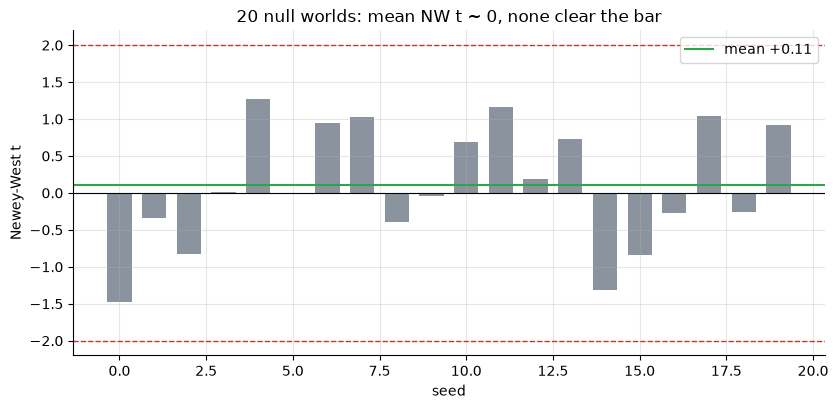

mean NW t (20 seeds): 0.111 | clearing |t|>=2: 0 / 20


In [3]:
ts = [st.predictive_regression(data.synthetic_series(beta=0.0, seed=s)[0], 'nflx_fwd')['t_nw']
      for s in range(551, 571)]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
cols = [RED if abs(t)>=2 else GREY for t in ts]
ax.bar(range(len(ts)), ts, color=cols, width=.7)
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.axhline(np.mean(ts), c=GREEN, lw=1.5, label=f'mean {np.mean(ts):+.2f}')
ax.axhline(0, c='k', lw=.8); ax.set_xlabel('seed'); ax.set_ylabel('Newey-West t')
ax.set_title('20 null worlds: mean NW t ~ 0, none clear the bar'); ax.legend()
plt.tight_layout(); plt.show()
print('mean NW t (20 seeds):', round(float(np.mean(ts)),3), '| clearing |t|>=2:', int(np.sum(np.abs(ts)>=2)), '/ 20')

> 💡 In plain words: over 20 seeds the mean NW *t* is **+0.11** and **0/20** clear \|*t*\| ≥ 2. The seed-551 draw was a false positive. No signal.

### 4c · The horizon-overlap artifact + the XLY spillover — H₂ & H₃

Left: sweep forward horizons — watch the *naive* OLS *t* balloon (more overlap = more fake significance) while the NW *t* stays modest. Right: the XLY spillover leg.

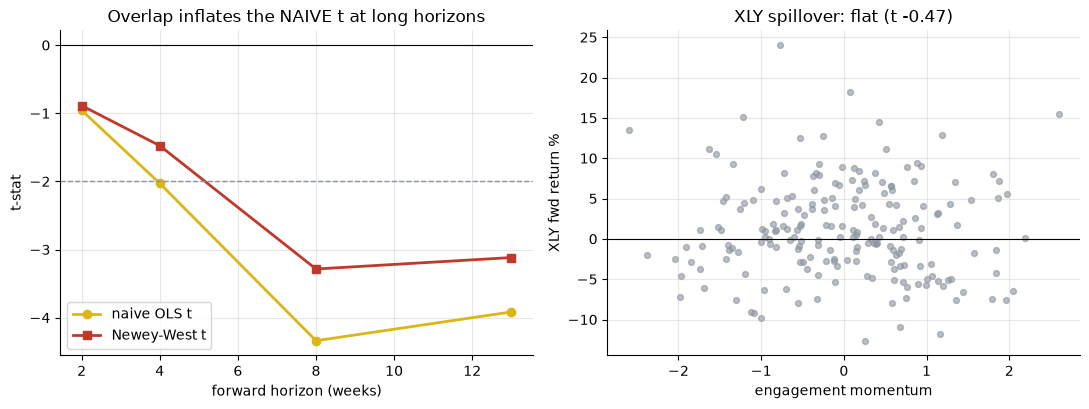

horizon (h, ols_t, nw_t): [(2, -0.96, -0.89), (4, -2.03, -1.48), (8, -4.34, -3.29), (13, -3.92, -3.12)]
XLY slope -0.0020, t -0.47, corr -0.03


In [4]:
hz = [(h,) + tuple(st.predictive_regression(data.synthetic_series(beta=0.0, horizon=h, seed=SEED)[0], 'nflx_fwd')[k]
      for k in ('slope_t','t_nw')) for h in (2,4,8,13)]
hzs = [r[0] for r in hz]; ols = [r[1] for r in hz]; nw = [r[2] for r in hz]
regx = st.predictive_regression(WEEKLY, 'xly_fwd')
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.plot(hzs, ols, 'o-', c=AMBER, lw=2, label='naive OLS t')
a1.plot(hzs, nw, 's-', c=RED, lw=2, label='Newey-West t')
a1.axhline(-2, ls='--', c=GREY, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_xlabel('forward horizon (weeks)'); a1.set_ylabel('t-stat')
a1.set_title('Overlap inflates the NAIVE t at long horizons'); a1.legend()
a2.scatter(WEEKLY['eng_mom'], WEEKLY['xly_fwd']*100, s=18, color=GREY, alpha=.6)
a2.axhline(0, c='k', lw=.8)
a2.set_xlabel('engagement momentum'); a2.set_ylabel('XLY fwd return %')
a2.set_title(f"XLY spillover: flat (t {regx['slope_t']:+.2f})")
plt.tight_layout(); plt.show()
print('horizon (h, ols_t, nw_t):', [(h, round(o,2), round(n,2)) for h,o,n in hz])
print(f"XLY slope {regx['slope']:+.4f}, t {regx['slope_t']:+.2f}, corr {regx['corr']:+.2f}")

> 💡 In plain words: **H₃ rejected** — the naive *t* grows with horizon purely because longer windows overlap more (a 13-week return shares 12 weeks with the next), a null artifact, not signal. **H₂ rejected** — the XLY spillover is flat (*t* -0.47); engagement, even if it moved NFLX, would not mechanically move the whole consumer basket.

## 5 · The verdict

- **Signal `NONE`** — no real tape (synthetic-only); H₁ unsupported (NW *t* -1.48, seed-mean +0.11, 0/20 clear the bar); H₂/H₃ rejected.
- **Tradability `MIRAGE`** — timing -3.6%/yr gross vs buy-and-hold +21.8%/yr.
- **Alt-data edge? `MIRAGE`** — an overlap false positive on data you cannot even buy.

## 6 · Could you trade it? — costs and the borrow

Long/flat and long/short timing on $m_t$, gross and net, against buy-and-hold.

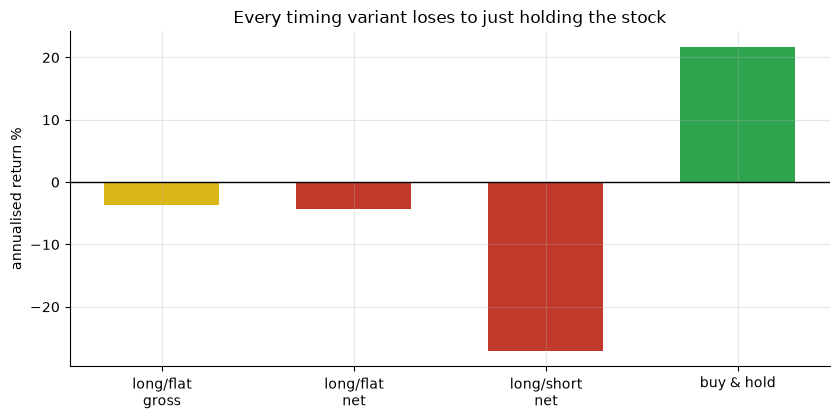

long/flat gross -3.6% net -4.4% | long/short net -27.1% | buy&hold +21.8%


In [5]:
lf = st.timing_backtest(WEEKLY, 'nflx_ret', allow_short=False, cost_bps=5.0)
ls = st.timing_backtest(WEEKLY, 'nflx_ret', allow_short=True, cost_bps=5.0, borrow_ann_bps=100.0)
labels = ['long/flat\ngross','long/flat\nnet','long/short\nnet','buy & hold']
vals = [lf['gross_ann']*100, lf['net_ann']*100, ls['net_ann']*100, lf['buyhold_ann']*100]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [AMBER, RED, RED, GREEN]
ax.bar(labels, vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised return %')
ax.set_title('Every timing variant loses to just holding the stock')
plt.tight_layout(); plt.show()
print(f"long/flat gross {lf['gross_ann']*100:+.1f}% net {lf['net_ann']*100:+.1f}% | long/short net {ls['net_ann']*100:+.1f}% | buy&hold {lf['buyhold_ann']*100:+.1f}%")

> 💡 In plain words: timing on a noise signal churns costs and misses upside; shorting the low-engagement weeks (and paying a borrow) is worse still. Nothing to harvest. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real engagement→return link (β > 0) of increasing strength and watch the **overlap-robust** NW *t* climb — averaged over 25 seeds so no single lucky seed can fake it.

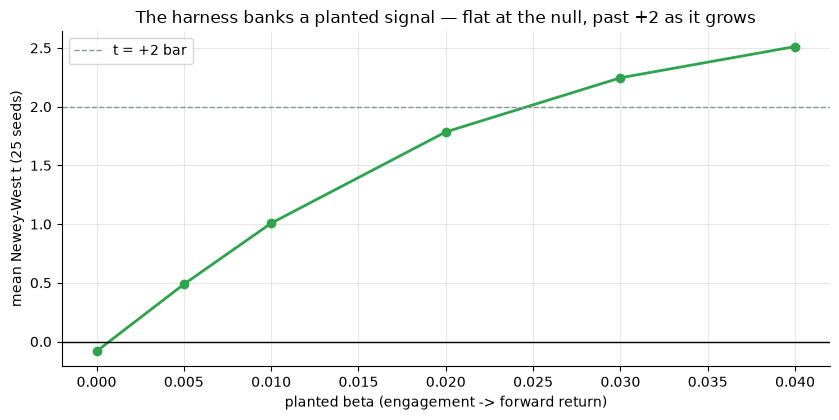

beta +0.000 -> mean NW t -0.08
beta +0.005 -> mean NW t +0.49
beta +0.010 -> mean NW t +1.01
beta +0.020 -> mean NW t +1.78
beta +0.030 -> mean NW t +2.25
beta +0.040 -> mean NW t +2.51


In [6]:
betas = [0.0, 0.005, 0.010, 0.020, 0.030, 0.040]
ts = [st.synthetic_mean_t(data, beta=b, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(betas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = +2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted beta (engagement -> forward return)')
ax.set_ylabel('mean Newey-West t (25 seeds)')
ax.set_title('The harness banks a planted signal — flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(betas, ts): print(f'beta {b:+.3f} -> mean NW t {t:+.2f}')

The NW *t* is ≈ 0 at the null and climbs past +2 as the planted link grows — so the engine is a faithful detector *even under the overlap correction*. The null-world non-result is therefore a statement about **the data and the overlap trap**, not the code. For sibling alt-data signals see [257 AAII](../../257-aaii-sentiment/), [335 Buzz](../../335-buzz-sentiment-etf/) and [392 Glassdoor](../../392-glassdoor-sentiment/).